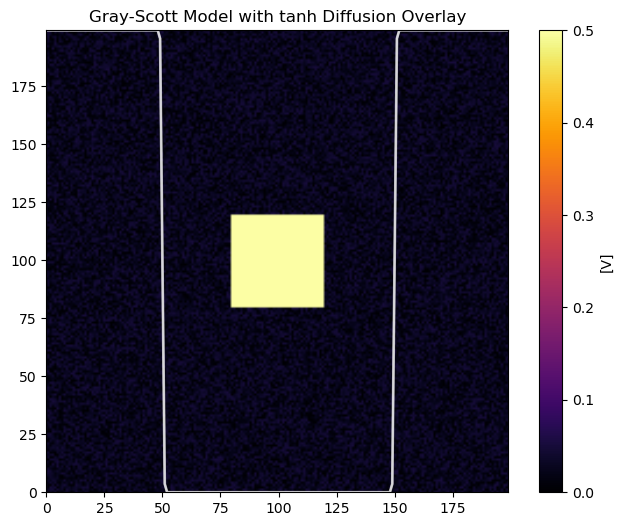

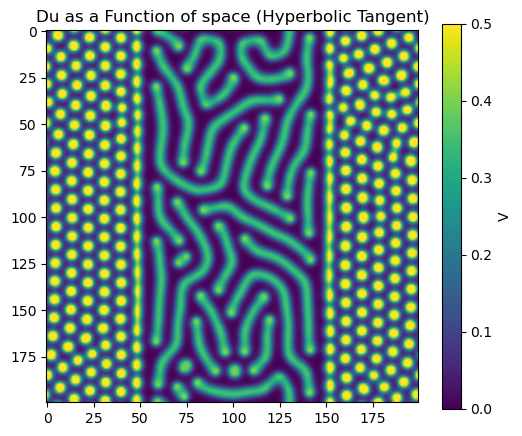

n_vector [[1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 ...
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]
 [1. 1. 1. ... 1. 1. 1.]]
Rank 1: Bin center = 0.8999, Frequency = 20814
Rank 2: Bin center = 2.6998, Frequency = 1085
Rank 3: Bin center = 4.4996, Frequency = 1057


AttributeError: 'numpy.ndarray' object has no attribute 'append'

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


F, k =  0.046, 0.064 #(Stripes) #0.028, 0.064 (Dots) #0.010, 0.046 (Dynamic) #0.037, 0.06 (Standard)
N = 200
L = 200
dx = L / N
height = 3
dy = dx
n_steps =  400 #10000 #Using 300 for video. 
p1 = 50
p2 = 200-p1
s = 0.1 #this will control how sharp the chnage in concentration will be at the boundry p1 and p2
x = np.linspace(0,L,N,endpoint=False)
y = np.linspace(0,L,N,endpoint=False)

scale = 0.16

s = list(range(1,6))
values_to_plot = np.zeros(1)

for p in s:
    input1 = s[p] * (x - p1) #so, this creates a bunch of values between the two boundries and creates them into inputs for the tanh functions
    input2 =  s[p] * -1 * (x - p2)
    tanfunc =   scale * ((height - 1)/2 * (2-np.tanh(input1) - np.tanh(input2)) +1) #now that we have a bunch of values between these two boundries, we can use the tanh function to create a bunch of diffusion constants between those two boundries
    Du =  np.full((N,N), tanfunc) #Now a bunch of diffusion constants are created between those two boundries which all change. Each is slightly different, but the main change is at 25 and 75. So after those, the 
    #diffusion constants are much lower. Currently, with sharpess = 0.1, and pi = 25 with p2 = 75, the diffusion constants are between 0 and 2. So we can define Dv later with the same process, maybe just saying that Dv = 2 * Du
    Dv =  (scale/2) * np.ones_like(Du)  # Dv = 0.08 For now I have placed Dv = Du/2 because that is the ratio we have been using so far. I still don't know why works, but it does.

    dt = ((dx)**2)/(4 * Du.max())-0.1 #This is the time step, which is based on the diffusion constant. This is a function for the time step. 



    def first_derivative(M, axis):
        firstD = (np.roll(M, 1, axis) - np.roll(M, -1, axis)) / (2 * dx)
        return firstD
            
    def combined_derivative(D, Concentration):
        dD_dx = first_derivative(D, 0)
        dU_dx = first_derivative(Concentration, 0)
        dD_dy = first_derivative(D, 1)
        dU_dy = first_derivative(Concentration, 1)
        return dD_dx * dU_dx + dD_dy * dU_dy


    def laplacian(Z, dx):
        d2Z_dx2 = np.roll(Z, 1, 0) - 2 * Z + np.roll(Z, -1, 0)
        d2Z_dy2 = np.roll(Z, 1, 1) - 2 * Z + np.roll(Z, -1, 1) 

        derivative = (d2Z_dx2 + d2Z_dy2)/(dx * dx) 
        # should this not be (d2Z_dx2/dx * dx) + (d2Z_dy2/dy * dy)? I think we are saying that 
        #dy = dx. So it doesn't matter and we combine like terms. 
        return derivative

    def solver(U, V, Du, Dv, F, k, dx, dt):
        Lu = laplacian(U, dx)
        Lv = laplacian(V, dx)

        uvv = U * V * V

        U += (Du * Lu + combined_derivative(Du,U) - uvv + F * (1 - U)) * dt
        V += (Dv * Lv + combined_derivative(Dv,V) + uvv - (F+k) * V) * dt
        #Here is forward euler's method for the next time step. 
        return U, V


    U = np.ones((N,N))
    V = np.zeros((N,N))


    r = 20
    U[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.75 #orginally was 0.50
    V[N//2 - r:N//2+r, N//2 - r: N//2 + r] = 0.50 #orginally was 0.25
    U += 0.05 * np.random.rand(N,N)
    V += 0.05 * np.random.rand(N,N)

    fig, ax = plt.subplots(figsize=(8,6)) #regular sizing in a cube

    im = ax.imshow(V, cmap='inferno', interpolation='bilinear', vmin=0, vmax=0.5)
    plt.axis('on')
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label('[V]')

    tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

    # x-coordinates: pixel indices (0 to N-1)
    x_coords = np.arange(N)

    # Overlay line: static sine curve
    tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=1.5, alpha=0.6)

    # Set axes to avoid autoscaling that might hide the line
    ax.set_xlim(0, N-1)
    ax.set_ylim(0, N-1)

    ax.set_title('Gray-Scott Model with tanh Diffusion Overlay')

    # def update(frame, U, V, Du, Dv, F, k, dx, dt, tanh_line):
    #     for _ in range(100):
    #         U, V = solver(U, V, Du, Dv, F, k, dx, dt)
    #     im.set_array(V)
    #     return [im, tanh_line]
    # ani = animation.FuncAnimation(fig, update, frames=n_steps, interval = 0.1, blit=True, fargs=(U, V, Du, Dv, F, k, dx, dt, tanh_line))
    # #ani.save('Gray_Scott_Animation.mp4', writer='ffmpeg', fps=30, dpi=300) #Save the animation as a video file

    ''' SOLVE FOR CONCENTRATIONS '''

    total_V_concentration = np.zeros(n_steps)
    total_time = np.zeros(n_steps)

    for i in range(n_steps):
        for _ in range(100):
            U, V = solver(U, V, Du, Dv, F, k, dx, dt)
        
        total_time[i] = i * dt 
        total_V_concentration[i] = np.mean(V)

    # ''' PLOT FINAL TIMESTEP '''

    plt.figure(figsize=(6,5))
    tanh_y = (tanfunc - tanfunc.min()) / (tanfunc.max() - tanfunc.min()) * (N - 1)

    # x-coordinates: pixel indices (0 to N-1)
    x_coords = np.arange(N)

    # Overlay line: static sine curve
    tanh_line, = ax.plot(x_coords, tanh_y, color='white', linewidth=2, alpha=0.6)


    plt.imshow(V, cmap='viridis', interpolation='bilinear', vmin=0, vmax=0.5)
    plt.title('Du as a Function of space (Hyperbolic Tangent)')
    plt.colorbar(label='V')
    plt.show()


    dVx = first_derivative(V, 1)
    dVy = first_derivative(V, 0)

    x2, y2 = np.meshgrid(np.arange(N), np.arange(N))

    mask1 = x2 < p1
    mask2 = x2 > p2


    final_mask = mask1 | mask2

    dVx2 =~final_mask * dVx
    dVy2= ~final_mask * dVy

    skip = 1
    # Downsample both coordinate grids and vector components consistently
    x_ds = x2[::skip, ::skip]
    y_ds = y2[::skip, ::skip]
    dVx_ds = dVx2[::skip, ::skip]
    dVy_ds = dVy2[::skip, ::skip]

    n_vectorx = dVx/np.sqrt(dVx**2 + dVy**2) 
    n_vectory = dVy/np.sqrt(dVx**2 + dVy**2)

    print('n_vector', np.sqrt(n_vectorx**2 + n_vectory**2))

    n_vector = [n_vectorx, n_vectory]

    #n_vector = dVx2/np.sqrt(dVx2**2 + dVy2**2)

    a = [1,0]

    def dot_product(a, b):
        return a[0]*b[0] + a[1]*b[1]

    cos_sq_theta = (dot_product(n_vector,a))**2 
    #print(cos_sq_theta)

    cos_2_theta = 2 * cos_sq_theta - 1

    theta = 0.5 * np.arccos(cos_2_theta)

    theta = theta * (180/np.pi) #convert to degrees

    theta =~final_mask * theta #USE FOR INNER SECTION
    #theta =~final_mask_edge * theta #USE FOR EDGE SECTION


    counts, bin_edges = np.histogram(theta, bins=50)

    # Sort counts in descending order and get top 3 indices
    top_indices = np.argsort(counts)[::-1][:3]

    # Get the bin centers and their counts
    top_bins = [( (bin_edges[i] + bin_edges[i+1]) / 2, counts[i]) for i in top_indices]

    # Print results
    for rank, (center, freq) in enumerate(top_bins, start=1):
        print(f"Rank {rank}: Bin center = {center:.4f}, Frequency = {freq}")


    bins = np.linspace(-0, 180, 41)
    #bins = np.linspace(-180,180,41)

    '''The JUICE'''
    counts, bin_edges = np.histogram(theta, bins=bins)

    bin_centers = (bins[1:] + bins[:-1]) / 2

    values_to_plot.append(np.mean(theta))

plt.plot(s, values_to_plot[1:],'o-')









In [10]:
import numpy as np
mylist = np.zeros(1)
mylist.append(5)

print(mylist)

AttributeError: 'numpy.ndarray' object has no attribute 'append'